## statistical learning analysis and algrothm in biology (sequence) analysis

**1. 序列比对**  
< Biological sequence analysis > is a very good book and it contains many important concepts and foundational methodologies that are rooted in some cutting-edge methods, e.g. psmc, described in the following notes. In fact, I think that a lot of state-of-art technologies are rooted in some old knowledge, as well as e.g. for recent parallel/convergent evolution research. So those classical book are really worth reading. < Biological sequence analysis > present several key issues for sequence alignment: (1) what sorts of alignment should be considered. (2) the scoring system used to rank alignments. (3) the algorithm used to find good scoring alignments and (4) the statistical methods used to evaluate the significance of an alignment score.  
(a)  
HBA_HUMAN GSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKL  
&emsp; &emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;     G+ +VK+HGKKV A+++++AH+D++ +++++LS+LH KL  
HBB_HUMAN GNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKL  
(b)  
HBA_HUMAN GSAQVKGHGKKVADALTNAVAHV---D--DMPNALSALSDLHAHKL  
&emsp; &emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;++ ++++H+ KV + +A ++ +L+ L+++H+ K  
LGB2_LUPLU NNPELQAHAGKVFKLVYEAAIQLQVTGVVVTDATLKNLGSVHVSKG  
(c)  
HBA_HUMAN GSAQVKGHGKKVADALTNAVAHVDDMPNALSALSD----LHAHKL  
&emsp; &emsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;GS++ G + +D L ++ H+ D+ A +AL D ++AH+  
FllGll.2 &emsp; &nbsp; &nbsp;&nbsp;&nbsp;&nbsp; GSGYLVGDSLTFVDLL--VAQHTADLLAANAALLDEFPQFKAHQE  

(c)为一个spurious high-scoring alignment to a nematode glutathione S-transferase homologue named F11G11.2. 如何区分(b),structurally plausible alignment to leghaemoglobin from yellow lupin,与(c)是一个挑战。有时无法区分，比如此处很难找到true alignment——(b)的两序列之间显著的相似性。

比对算法就是对两条序列的比对，逐个字符对进行打分，最终找到一个总加和得分最高的比对，匹配度高的应当得到较高的分，虽然一般DNA比对，不区分不同碱基的比对，两序列某个位点只要碱基相同的比对，都给相同的得分，不同碱基的比对就给相同的失配分，但是本书主要从蛋白质比对开始着手讲解，蛋白质比对会用到一个substitution matrix, 对于不同氨基酸的比对有不同的得分。这对于理解包括DNA比对在内的比对的生物学意义或者说进化上是否是相关的，非常有意义。对于两条序列的比对，这个打分实际给出了一种关于两条序列是有进化关系的还是随机的的一种相对测量，相当于以随机模型作为背景，计算有关系的匹配模式与随机配对模式的相对似然比。
The unrelated or random model R assumes that letter a occurs independently with some frequency qₐ, the probability of the two sequences is just the product of the probabilityes of each amino acid:(假设等长序列，每对出现的概率为各自独立概率的乘积)  
$$ P(x,y|R)=\prod_{i}{(q_{x_i}q_{y_i})} $$

  
In the alternative match mode M, 比对的字符对出现的概率是一个联合概率${P_{ab}}$. ${P_{ab}}$的值可以视作是从a和b的共同祖先,一个未知字符c，独立发生取代，衍生出a和b的概率（c可能和a或/和b相同）。  
this gives a probability for the whole alignment of 
$$P(x,y|M)=\prod_{i}{p_{xᵢyᵢ}}$$
The ratio of these two likelihoods is known as the odds ratio:
$$ {P(x,y|M) \over P(x,y|R)}={\prod_{i}{p_{xᵢyᵢ}}\over \prod_{i}{q_{x_i}}\prod_{j}{q_{y_j}}}=\prod_{i}{p_{xᵢyᵢ} \over q_{x_i}q_{y_i}}            $$
in order to arrive at an additive scoring system, we take the logarithm of this ratio, known as the log-odds ratio:
$$S=\sum_{i}{s(xᵢ,yᵢ)}\tag{6.2}$$
其中的s(xᵢ,yᵢ)实际上是每对比对的字符的得分为：
$$s(a,b)=log({P_{ab} \over q_aq_b})\tag{6.3}$$
如我们所愿，方程2.2是一个对所有单个比对字符对的得分s(a,b)的加和。 s(a,b)的得分可以排成矩阵。比如对蛋白质来说，形成一个20×20的矩阵，i行j列的值s(aᵢ,aⱼ)， aᵢ,aⱼ为在一些氨基酸编号中第i和j号氨基酸。这就是一个 score matrix 或者 substitution matrix. 一个例子是 BLOSUM50 matrix, shown in Figure 2.2，其推导本质上如上述. 用这些值可以对上面的比对计分，(a)得到130分。另一个常用的 substitution matrices 集合是称为PAM的matrices.  
一个重要的结果是，既是一个凭经验的生物学家随手（ad hoc意为for this）写一个subsitution matrix, 这个subsitution matrix都隐含一个根据上述理论的目标频率${P_{ab}}$
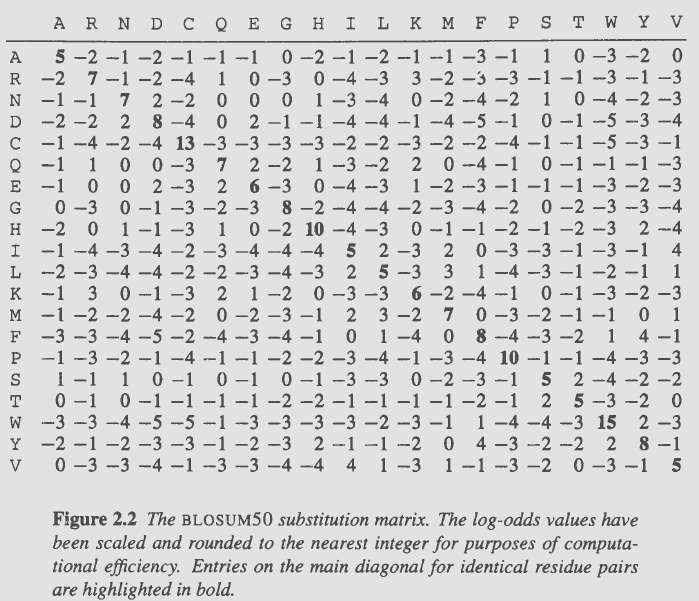  
这个subsitiution matrix用来对比对打分，但是DNA比对基本不用，但是这个思想可以用来理解DNA比对得分到底反应了什么生物学意义。   

i）全局序列比对---Needleman-Wunsch algorithm  
如果考虑所有插入空格的比对方法，情况将是指数级随长度增长。实际采用动态比对算法。  
生成一个记录前缀最佳比对得分的相似性矩阵，第一行即最上一行和最左一列填入空格罚分的累加。相似矩阵的每个元素entry(i,j),也即sim(s[1...i],t[1...j])通过查询前三项entry(i-1,j),entry(i-1,j-1),entry(i,j-1)来计算。
$$entry(i,j)=max\begin{cases}
entry(i,j-1)-g,\\
entry(i-1,j-1)+s(x_i,y_j)\\
entry(i-1,j)-g
\end{cases}\tag{6.4}$$
通过回溯矩阵到左上角的到最优比对。

implemented in [module of alignment.py](practice_code/similarity.c)


ii) 局部比对算法---Smith-Watherman algorithm

如前所述，这个得分系统实际上是log relative likelihood,可以测算两条比对的序列是否有（homology）关系还是纯随机。(6.2式也可写成如下表述)
$$S=log{P(alignment|homology) \over P(alignment|random)}$$
局部比对算法是要在比对进入相对随机的比对状态时，例如蛋白序列功能域以外的区域，DNA内含子或基因间区，使用一个阈值终止比对。这个阈值选择0。所以其比对算法就是在全局比对算法公式(6.4)中加一个0,当3个可能的来源都使该entry(i,j)<0,则entry(i,j)=0.下面来理解一下他统计上的生物学意义。例如在无gap比对的情况下，各个位点的比对都是独立，对氨基酸序列的比对只需要考虑一个位点的期望得分
$$E(s)=\sum_{a,b}{q_sq_bs(a,b)}<0$$
相对熵定理总是保证E(s)<0,因为....
公式表明，每一个比对碱基（或氨基酸）平均能够提供多少关于"它们来自同源序列而不是随机序列"的信息。
所以在纯随机情况下，所得分的期望是负的。若要得分为正，必须有同源序列。本质上是随机背景是一个"负漂移（negative drift）"过程。只有偶然出现的一小段真正相似的区域，才能克服这种负漂移，形成具有统计学意义的高分局部比对。这也是整个 BLAST 统计理论能够成立的根本条件。

测算得分公式为：   
局部比对算法要起作用，随机匹配的期望得分  

iii) 半全局比对





**8. some interesting and useful ideas on sequence and motif analysis**  
look G4 motif as an example, ['Prevalence of quadruplexes in the human genome' Julian L. Huppert and Shankar Balasubramanian*](https://academic.oup.com/nar/article/33/9/2908/2401500) applied some mathmatic tech/models to analysis this motif in human genome NCBI build 34.
"Understanding the prevalence is important, because it leads to the identification of more sequences of potential biological interest, and also because in order for quadruplexes to be useful as therapeutic targets, a quadruplex ligand must ideally be specific for only one quadruplex in the genome."  
统计参考基因组序列上的G-pattern (即$(GGG)_{3\_5}N_{1\_7})_{>4}$)和C-pattern(即$(CCC)_{3\_5}N_{1\_7})_{>4}$)的数量，因为可以在互补链形成G-pattern从而形成G4元件。
4 runs of Gs若有多种可能计数方式的按一种计算。
超过4runs of Gs 按连续能形成的最多不重叠的G4数量计数。如 $d(GGGTTA)_8$ 计两个（也有用重叠方式计5个）  
软件扫描元件数量统计结果（A- T-pattern用作对照）  
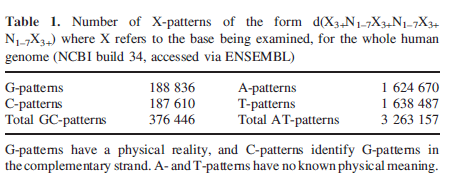  
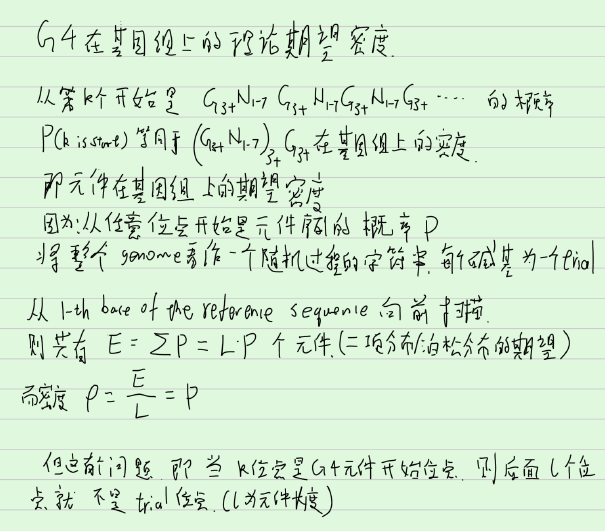  
G4元件的理论期望密度： 
P(k is start)=P(3G bases)^4*P(one appropriate loop)^3=  
按公式计算出理论期望的G4数量（与对照A- T-pattern的数量都）远小于实际统计得到的。可能因为"some bases are more likely to occur after others."，"DNA is not homogenous with respect to base composition, and has regions that are relatively rich in each base"  
将简单的Bernoulli model 扩展为碱基前后概率关联的二阶马尔可夫模型  
按窗口扫描全基因组，每个窗口内统计二联体的数量，用得到的diad frequencies 4×4 矩阵作为下一个碱基的转移概率。生成一个simulated genome
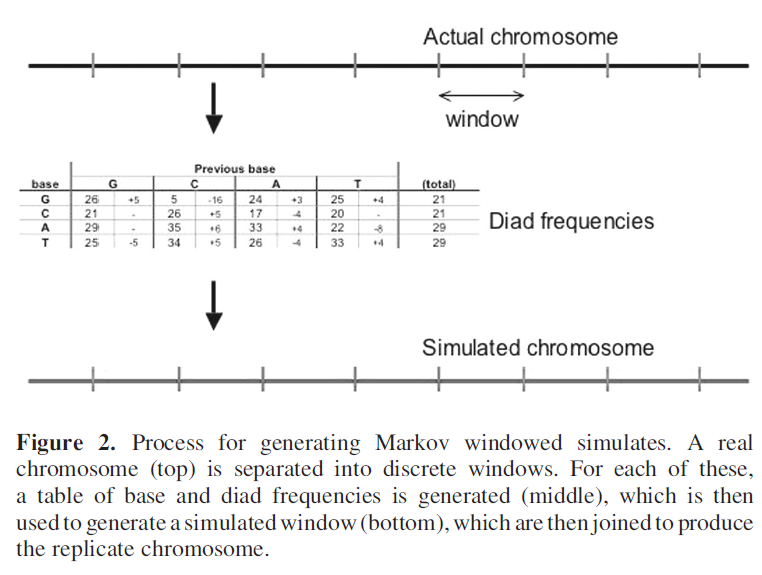  
统计G4元件的数量作为理论期望值。用软件扫描其中的元件数量，不同窗口(50 -4k bp)模拟得到的基因组，统计出的G4元件数量差距很大，大的窗口会变少。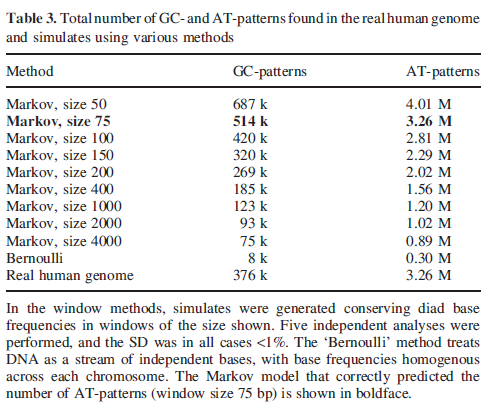  
"The ratios of patterns for each base under different simulation conditions are shown in Table 4 for each case, normalized to the predicted number of T-patterns = 1. This shows that in all cases, a ‘pseudo-Chargaff’ rule applies, with roughly as many G-patterns as C-patterns, and similarly with A and T."


https://www.nature.com/collections/aebdjihcda
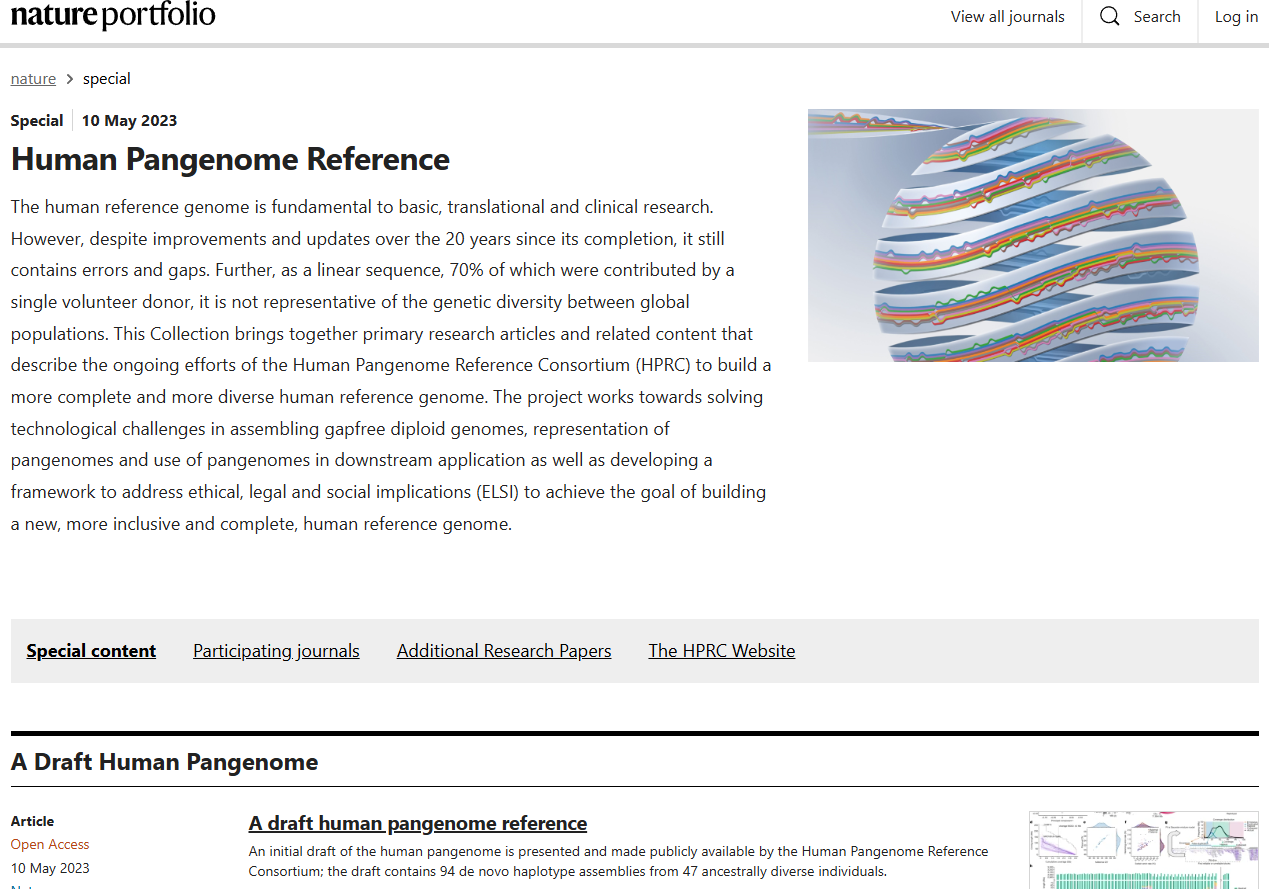
虽然大多数着丝粒预计是一个单一的动粒附着点，但表观遗传学分析表明，7%的着丝粒存在两个低价甲基化区域。

**9. graph genome assembly**  
snarls 和 ultrabubbles, 是双向图和边图中的superbubbles的推广
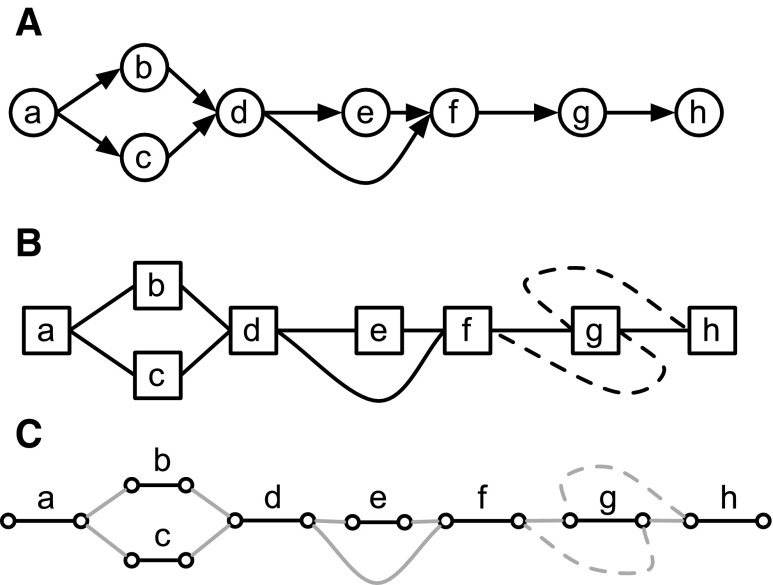  
A为有向图（digraph）
B为双向图 bidirected graph D=($V_D,E_D$)，每个边的两端有独立的方向，由他连接到方框的左侧还是右侧决定。
C是另一种表示
B图虚线以外的图表示等价于A的图


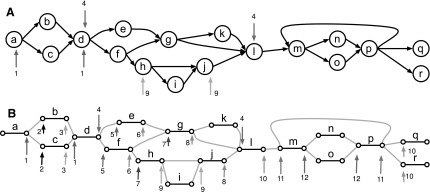